# Interactive Blackbody Animation

This notebook uses widgets to illustrate blackbody temperature.

\begin{equation}
B_\nu(T) = \frac{2h\nu^2}{c^3}\frac{1}{e^\frac{h\nu}{k_BT} - 1}
\end{equation}

\begin{equation}
B_\lambda(T) = \frac{2hc^2}{\lambda^5}\frac{1}{e^\frac{hc}{\lambda k_BT} - 1}
\end{equation}

In [1]:
# if you get a widget error, run this:
#!pip install ipympl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings('ignore')

# Prevent mathtext parsing errors with widget backend
plt.rcParams['axes.formatter.use_mathtext'] = False

%matplotlib widget

In [3]:
# High-level parameters
SIZE = 2048     # number of points in each line
T0 = 4.     # log10 K, temperature of blackbody
LAM_MIN = -8
LAM_MAX =  0
NU_MIN = 10 - LAM_MAX
NU_MAX = 10 - LAM_MIN

# Constants
h = 6e-27  # erg s
c = 3e10  # cm / s
k_B = 1.3e-16 # erg / K

# Variables derived from parameters above
nus = np.logspace(NU_MIN, NU_MAX, SIZE)
lam = np.logspace(LAM_MIN, LAM_MAX, SIZE)

RP = (640e-7, 1050e-7) # cm
BP = (330e-7, 680e-7) # cm
G  = (330e-7, 1050-7) # cm

interactive(children=(FloatSlider(value=3.0, description='Log10 Temperature [K]', max=5.0, min=3.0, style=Slid…

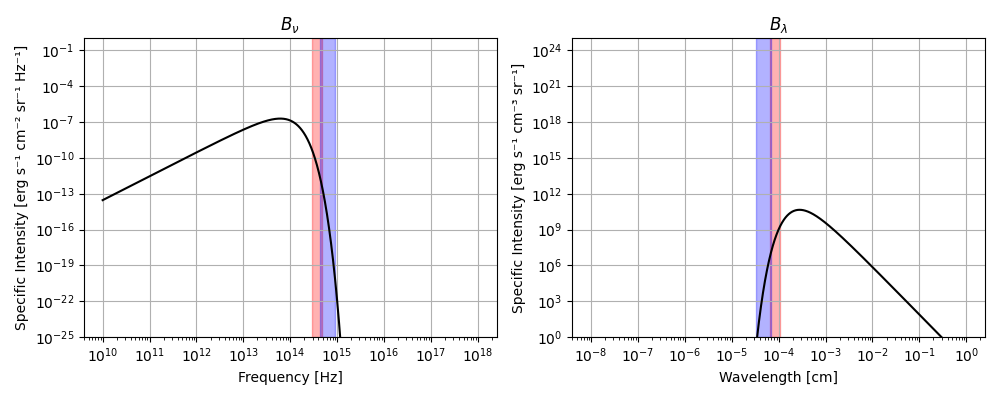

In [4]:
# Create the figure and set up axes
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))

# Configure axes
for _ax in ax:
    _ax.grid(True)
    _ax.set_yscale('log')
    _ax.set_xscale('log')

ax[0].set_title('$B_\\nu$')
ax[0].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel('Specific Intensity [erg s⁻¹ cm⁻² sr⁻¹ Hz⁻¹]')
ax[0].set_ylim(1e-25, 1e0)

ax[1].set_title('$B_\\lambda$')
ax[1].set_xlabel('Wavelength [cm]')
ax[1].set_ylabel('Specific Intensity [erg s⁻¹ cm⁻³ sr⁻¹]')
ax[1].set_ylim(1e0, 1e25)

# Add wavelength bands
ax[0].axvspan(c / RP[1], c / RP[0], color='red', alpha=0.3)
ax[0].axvspan(c / BP[1], c / BP[0], color='blue', alpha=0.3)
ax[1].axvspan(RP[0], RP[1], color='red', alpha=0.3)
ax[1].axvspan(BP[0], BP[1], color='blue', alpha=0.3)

# Create line objects (will be updated by interact)
bb_n, = ax[0].plot(nus, np.ones_like(nus), 'k')
bb_l, = ax[1].plot(lam, np.ones_like(lam), 'k')

plt.tight_layout()

def update_plot(log_T):
    """Update plots when slider changes."""
    T = 10**log_T
    y_n = 2 * h * nus**3 / c**2 / (np.exp(h * nus / (k_B * T)) - 1)
    y_l = 2 * h * c**2 / lam**5 / (np.exp(h * c / (lam * k_B * T)) - 1)
    bb_n.set_ydata(y_n)
    bb_l.set_ydata(y_l)
    fig.canvas.draw_idle()

interact(update_plot, log_T=FloatSlider(
    value=3,
    min=3,
    max=5,
    step=0.1,
    description='Log10 Temperature [K]',
    style={'description_width': 'initial'},
    continuous_update=True
));

We can try this with [marimo](https://marimo.io/) too:

```bash
uv run marimo run 05_demo_blackbody_marimo.py
```